Dataset shape: (20640, 8)

Model Performance (RMSE)
Linear: Train=0.7197, Test=0.7456
Ridge: Train=0.7197, Test=0.7456
Lasso: Train=0.8197, Test=0.8244
ElasticNet: Train=0.7920, Test=0.7974


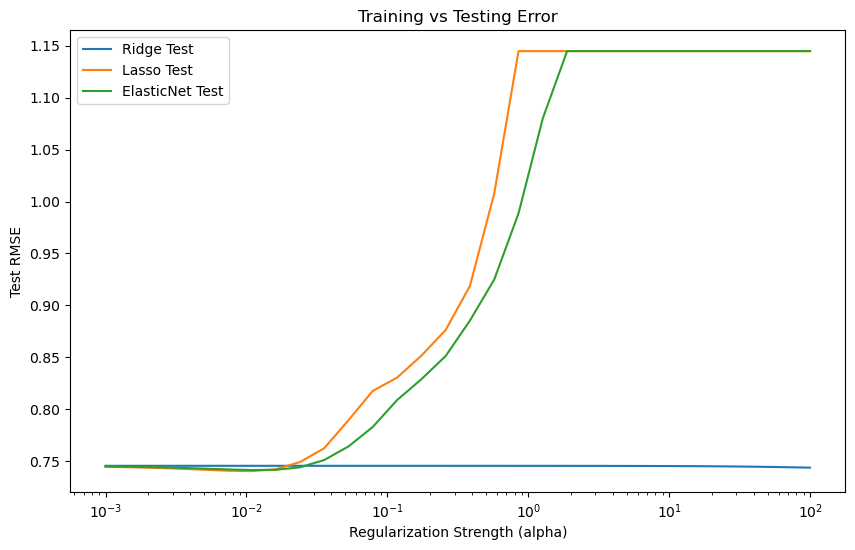

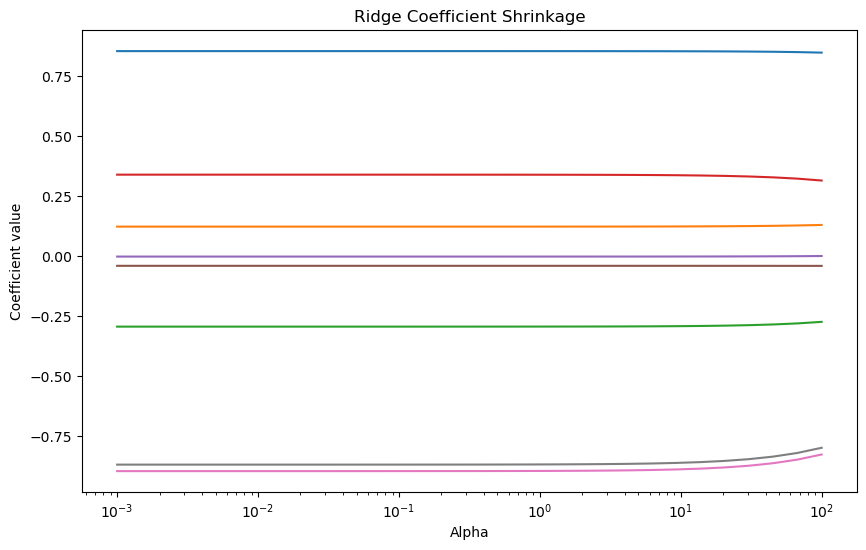

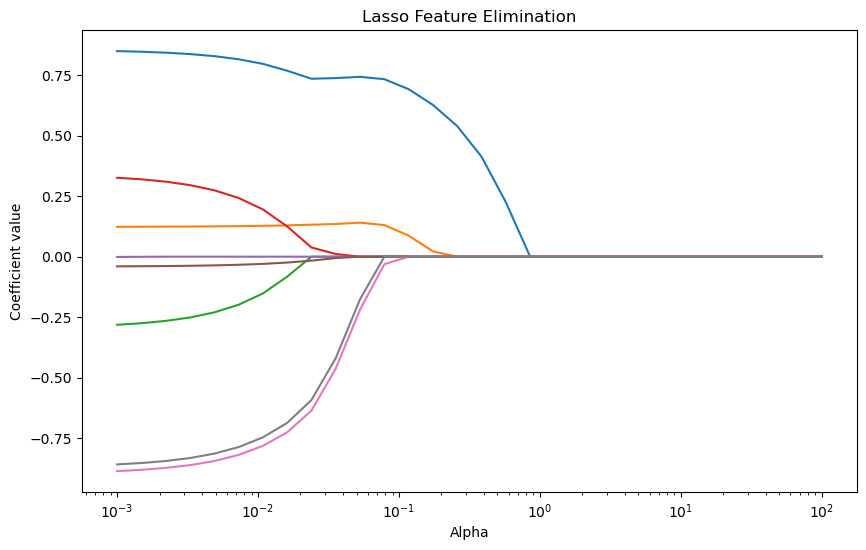

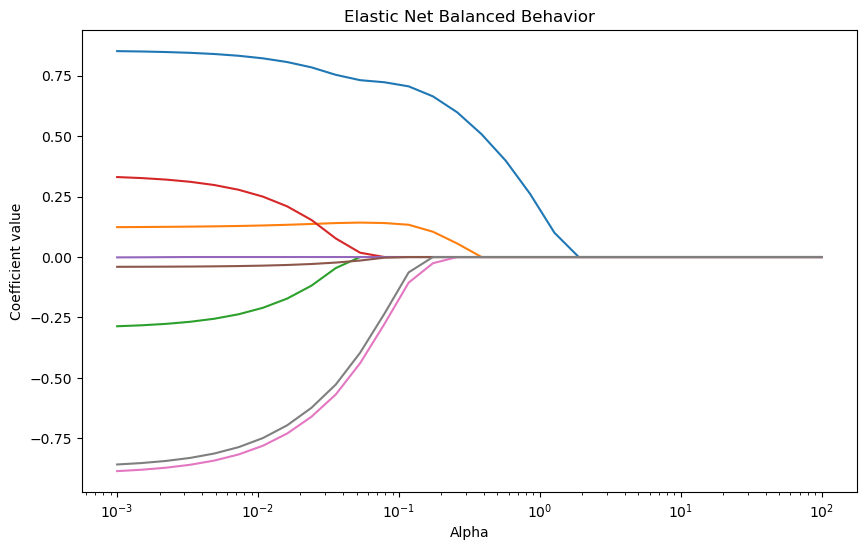

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    results[name] = (train_rmse, test_rmse)

print("\nModel Performance (RMSE)")
for name, (tr, te) in results.items():
    print(f"{name}: Train={tr:.4f}, Test={te:.4f}")

alphas = np.logspace(-3, 2, 30)

ridge_train, ridge_test = [], []
lasso_train, lasso_test = [], []
enet_train, enet_test = [], []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train_scaled, y_train)
    ridge_train.append(np.sqrt(mean_squared_error(y_train, r.predict(X_train_scaled))))
    ridge_test.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))

    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_train_scaled, y_train)
    lasso_train.append(np.sqrt(mean_squared_error(y_train, l.predict(X_train_scaled))))
    lasso_test.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

    e = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=10000)
    e.fit(X_train_scaled, y_train)
    enet_train.append(np.sqrt(mean_squared_error(y_train, e.predict(X_train_scaled))))
    enet_test.append(np.sqrt(mean_squared_error(y_test, e.predict(X_test_scaled))))

plt.figure(figsize=(10,6))
plt.plot(alphas, ridge_test, label="Ridge Test")
plt.plot(alphas, lasso_test, label="Lasso Test")
plt.plot(alphas, enet_test, label="ElasticNet Test")
plt.xscale("log")
plt.xlabel("Regularization Strength (alpha)")
plt.ylabel("Test RMSE")
plt.title("Training vs Testing Error")
plt.legend()
plt.show()

def plot_coefficients(model_class, title):
    coefs = []
    for a in alphas:
        model = model_class(alpha=a, max_iter=10000)
        model.fit(X_train_scaled, y_train)
        coefs.append(model.coef_)
    coefs = np.array(coefs)

    plt.figure(figsize=(10,6))
    for i in range(coefs.shape[1]):
        plt.plot(alphas, coefs[:, i])
    plt.xscale("log")
    plt.xlabel("Alpha")
    plt.ylabel("Coefficient value")
    plt.title(title)
    plt.show()

plot_coefficients(Ridge, "Ridge Coefficient Shrinkage")
plot_coefficients(Lasso, "Lasso Feature Elimination")
plot_coefficients(lambda alpha, max_iter=10000: ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=max_iter),
                  "Elastic Net Balanced Behavior")